In [26]:
import pandas as pd
import numpy as np
import sys
parent_path = '/mnt/digphat/syntheticDataBenchmark/Chuong_pipeline'
sys.path.append(parent_path)
from SynOmics.processing.postprocessing import post_masking
import scipy.stats as scp

corr_res = {}

def create_merged_clinical(dataset):
    if dataset == 'Origin':
        data = 'original_data'
    else:
        data = dataset
    raw_clinical = pd.read_csv(f'../NSCLC/Data/{data}.csv')
    un_mask_su2c_clinical = raw_clinical.iloc[:,0:29]
    su2c_clinical = post_masking(un_mask_su2c_clinical)
    su2c_clinical = su2c_clinical.rename(columns= {
        'Patient_ID': 'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'
    })
    su2c_clinical['Harmonized_Confirmed_BOR_Bin'] = su2c_clinical['Harmonized_Confirmed_BOR_3_Cat'].map({
        'PR/CR': 1, 'CR/PR': 1, 'PR': 1, 'CR': 1,
        'SD': 0, 'PD': 0
    })

    su2c_is_sf_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/SF_{dataset}.csv')
    su2c_is_sf_harm = su2c_is_sf_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_zi_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/ZI_{dataset}.csv')
    su2c_is_zi_harm = su2c_is_zi_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})
    
    su2c_is_hm_harm = pd.read_csv(f'../NSCLC/NarrowUtility/CellDeco/Signature_analysis/Other_{dataset}.csv')
    su2c_is_hm_harm = su2c_is_hm_harm.rename(columns = {'Patient_ID':
                                                       'Harmonized_SU2C_RNA_Tumor_Sample_ID_v2'})

    su2c_merge_master = su2c_clinical.merge(su2c_is_hm_harm.rename(columns = lambda x: x + '_HM'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_HM',axis=1)\
    .merge(su2c_is_sf_harm.rename(columns = lambda x: x + '_SF'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_SF',axis=1)\
    .merge(su2c_is_zi_harm.rename(columns = lambda x: x + '_ZI'),\
          left_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',how='left')\
          .drop('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2_ZI',axis=1)

    expression_data = raw_clinical.set_index('Patient_ID', drop=True).iloc[:, 28:]
    expression_data = expression_data.T
    expression_matrix = (expression_data
                     .replace([np.inf, -np.inf], 0)
                     .fillna(0)
                     .clip(lower=0))
    expression_data_log = expression_matrix.apply(lambda x: np.log(x+1))
    expression_data_log_norm = expression_data_log.T.apply(scp.zscore).T
    interested_genes = ['NHSL2', 'SLC27A3', 'SIPA1L2','AUTS2','TCF7L1','PRPF40A',
             'PSMB9','PSME1','PSME2']
    expression_data_log_norm_selected = expression_data_log_norm.loc[interested_genes]

    su2c_rna_harm_log_merge_mine = expression_data_log_norm_selected.T.merge(su2c_merge_master,left_index=True,
                                                                             right_on='Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',how='left')
    su2c_rna_harm_log_merge_mine.set_index('Harmonized_SU2C_RNA_Tumor_Sample_ID_v2',inplace=True)
    return su2c_rna_harm_log_merge_mine



def create_corr_matrix(data, select_cols):
    su2c_heatmap_mine = data[select_cols].corr().fillna(0)
    su2c_heatmap_renamed_mine = su2c_heatmap_mine.copy()
    return su2c_heatmap_renamed_mine

In [39]:
corr_res = {}
datasets = ['Origin', 'avatarsk5_42', 'avatarsk5_42', 'ctgan_42', 'gaussiancopula_42', 'synthpop_42', 'tvae_42']
names = ["Origin", "Avatars K5", 'Avatars K10','CTGAN',"Gaussian Copula", "Synthpop", "TVAE"]

for i, dataset in enumerate(datasets):

    metadata = create_merged_clinical(dataset)
    select_cols = ['hMono3_ZI', 'hN3_ZI',
       'Macrophages/Monocytes_SF', 'Adenosine (Corvus) (Willingham et al.)_HM',
       'NHSL2', 'EMT2 (PMID: 27321955)_HM',
       'TGF-B (Mariathasan Nature 2018)_HM', 'SLC27A3',
       'NFAT/NR4A1 family T cell dysfunction_HM', 'SIPA1L2',
       'AUTS2', 'TCF7L1',
       'PRPF40A',
       'Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM',
       'PSMB9',
       'Antigen processing machinery (PMID: 27855702)_HM', 'IFNG_HM',
       'PSME1', 'PSME2', 'PDL1_TPS']
    corr_matrix = create_corr_matrix(metadata, select_cols)
    corr_res[names[i]]=corr_matrix

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# =============================================================================
# INPUT: corr (correlation matrix)
# =============================================================================
# corr_matrix must be a DataFrame NxN, with corr_matrix.index == corr_matrix.columns
# and in the exact order you want to display.


# =============================================================================
# 1) Define groups + pretty label map (optional)
#    IMPORTANT: groups below must match ORIGINAL feature names in corr.columns
# =============================================================================
# ---- OPTIONAL: pretty labels for display ----
rename_map = {
    # Wound healing (Gọn & chuẩn)
    "hMono3_ZI": "hMono3 (Zilionas)",
    "hN3_ZI": "hN3 (Zilionas)",
    "Macrophages/Monocytes_SF": r"M$\phi$/Mono (Sade-Feldman)",
    "Adenosine (Corvus) (Willingham et al.)_HM": "A2AR (Willingham)",
    "NHSL2": r"$\it{NHSL2}$",
    "EMT2 (PMID: 27321955)_HM": "EMT (Hedegaard)",
    "TGF-B (Mariathasan Nature 2018)_HM": "TGF-$\beta$ (Mariathasan)",
    "SLC27A3": r"$\it{SLC27A3}$",
    "NFAT/NR4A1 family T cell dysfunction_HM": "NR4A1 (Chen)",
    "SIPA1L2": r"$\it{SIPA1L2}$",
    "AUTS2": r"$\it{AUTS2}$",
    "TCF7L1": r"$\it{TCF7L1}$",

    # Immune activation (Rút ngắn tối đa)
    "PRPF40A": r"$\it{PRPF40A}$",
    "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM": "T cell-inflamed (Ayers)",
    "PSMB9": r"$\it{PSMB9}$",
    "Antigen processing machinery (PMID: 27855702)_HM": "MHC-I (Senbabaoglu)",
    "IFNG_HM": "IFN-$\gamma$ Sig. (Gao)",
    "PSME1": r"$\it{PSME1}$",
    "PSME2": r"$\it{PSME2}$",
    "PDL1_TPS": "PD-L1 TPS",

    # Other
    "VGF": r"$\it{VGF}$",
}
# ---- Define groups as sets of ORIGINAL feature names (before renaming) ----
wound_healing = {
    "hMono3_ZI", "hN3_ZI", "Macrophages/Monocytes_SF", "Adenosine (Corvus) (Willingham et al.)_HM",
    "NHSL2", "EMT2 (PMID: 27321955)_HM", "TGF-B (Mariathasan Nature 2018)_HM",
    "SLC27A3", "NFAT/NR4A1 family T cell dysfunction_HM", "SIPA1L2",
    "AUTS2", "TCF7L1",
}

immune_activation = {
    "PRPF40A", "Merck/Nanostring 18 gene\xa0T cell–inflamed GEP score_HM", "PSMB9",
    "Antigen processing machinery (PMID: 27855702)_HM", "IFNG_HM",
    "PSME1", "PSME2", "PDL1_TPS",
}

other = {"VGF"}

# Original spec was positive/negative.
# Updated per request: use responder/nonresponder and colors consistent with immune cell palette.
# - Responder: green
# - Nonresponder: red
responder = set(immune_activation) | {"VGF"}
nonresponder = set(wound_healing)


# =============================================================================
# 2) Palettes (updated per request)
# =============================================================================
pal_cat = {
    "Wound healing": "#CC79A7",      
    "Immune activation": "#009E73", 
    "Other": "#9E9E9E",              # gray
    "Unassigned": "#BDBDBD",
}

# Use the same palette as your immune-cell "pal_assoc"
pal_assoc = {
    "Responder": "#0072B2",       
    "Nonresponder": "#D55E00",    
    "Unassigned": "#BDBDBD",
}


# =============================================================================
# 3) Build 2 color layers (must align with columns of matrix being plotted)
# =============================================================================
def build_color_layers_for_columns(cols: list[str]):
    cat = {}
    assoc = {}

    for c in cols:
        # Category layer
        if c in wound_healing:
            cat[c] = "Wound healing"
        elif c in immune_activation:
            cat[c] = "Immune activation"
        elif c in other:
            cat[c] = "Other"
        else:
            cat[c] = "Unassigned"

        # Association layer (updated names)
        if c in responder:
            assoc[c] = "Responder"
        elif c in nonresponder:
            assoc[c] = "Nonresponder"
        else:
            assoc[c] = "Unassigned"

    color_layer_category = pd.Series({c: pal_cat[cat[c]] for c in cols}, index=cols, name="Category")
    color_layer_assoc = pd.Series({c: pal_assoc[assoc[c]] for c in cols}, index=cols, name="Association")

    return color_layer_category, color_layer_assoc


# =============================================================================
# 4) Plot function (NO clustering; keep original order exactly)
# =============================================================================
def plot_corr_heatmap_with_two_layers(
    corr: pd.DataFrame,
    rename_map=None,
    figsize=(10, 10),
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    cbar_shrink=0.6,
):
    """
    Plot a correlation heatmap with two annotation color layers (category + association),
    keeping the exact input order (no clustering).

    Args:
        corr (pd.DataFrame): Square correlation matrix (NxN) with corr.index == corr.columns.
        rename_map (dict | None): Optional mapping for display names (applied after ordering).
        figsize (tuple): Figure size.
        vmin (float): Min correlation value for colormap.
        vmax (float): Max correlation value for colormap.
        cmap (str): Matplotlib colormap name.
        cbar_shrink (float): Colorbar shrink factor.

    Returns:
        sns.matrix.ClusterGrid: Seaborn ClusterGrid object (even though clustering is disabled).

    Raises:
        AssertionError: If corr is not a square DataFrame or index != columns.
    """
    assert isinstance(corr, pd.DataFrame)
    assert corr.shape[0] == corr.shape[1]
    assert list(corr.index) == list(corr.columns), "corr index must equal corr columns (same order)."

    # Build color layers in the ORIGINAL order
    cols = corr.columns.tolist()
    color_layer_category, color_layer_assoc = build_color_layers_for_columns(cols)

    # Rename labels for DISPLAY only
    if rename_map is not None:
        corr_plot = corr.rename(index=rename_map, columns=rename_map)
        color_layer_category.index = corr_plot.columns
        color_layer_assoc.index = corr_plot.columns
    else:
        corr_plot = corr

    # Plot heatmap using clustermap but with clustering disabled
    # (This keeps the two col_colors layers format from your original code.)
    g = sns.clustermap(
        corr_plot,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        row_cluster=False,
        col_cluster=False,
        col_colors=[color_layer_category, color_layer_assoc],
        figsize=figsize,
        xticklabels=True,
        yticklabels=True,
    )

    # Make dendrogram axes invisible (since we do not use clustering)
    g.ax_row_dendrogram.set_visible(False)
    g.ax_col_dendrogram.set_visible(False)

    # Colorbar formatting (simple + compact)
    g.ax_cbar.set_title("Correlation", fontsize=10)
    g.cax.set_position((0.02, 0.88, 0.02, 0.12))  # (x, y, w, h) in figure fraction
    g.cax.tick_params(labelsize=9)

    # Legends
    cat_handles = [
        mpatches.Patch(color=pal_cat[k], label=k)
        for k in ["Wound healing", "Immune activation"]
    ]
    assoc_handles = [
        mpatches.Patch(color=pal_assoc[k], label=k)
        for k in ["Responder", "Nonresponder"]
    ]

    plt.legend(
        handles=cat_handles + assoc_handles,
        bbox_to_anchor=(1.02, 1),
        bbox_transform=plt.gcf().transFigure,
        loc="upper left",
        title="Annotations",
        frameon=True,
        fontsize=10,
    )

    # Tick label formatting
    _ = g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xmajorticklabels(), fontsize=9, rotation=90)
    _ = g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_ymajorticklabels(), fontsize=9, rotation=0)
    g.ax_heatmap.yaxis.set_label_position("left")
    # plt.title(title, fontsize=12, fontweight="bold", pad=12)
    plt.show()
    return g

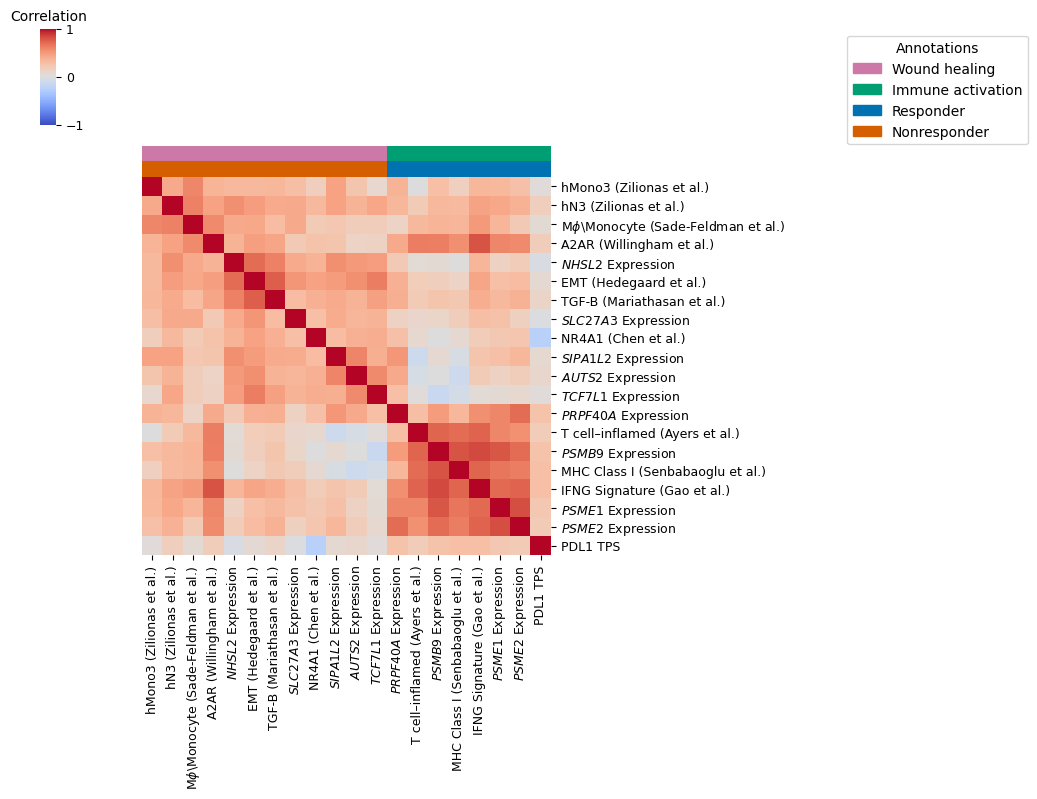

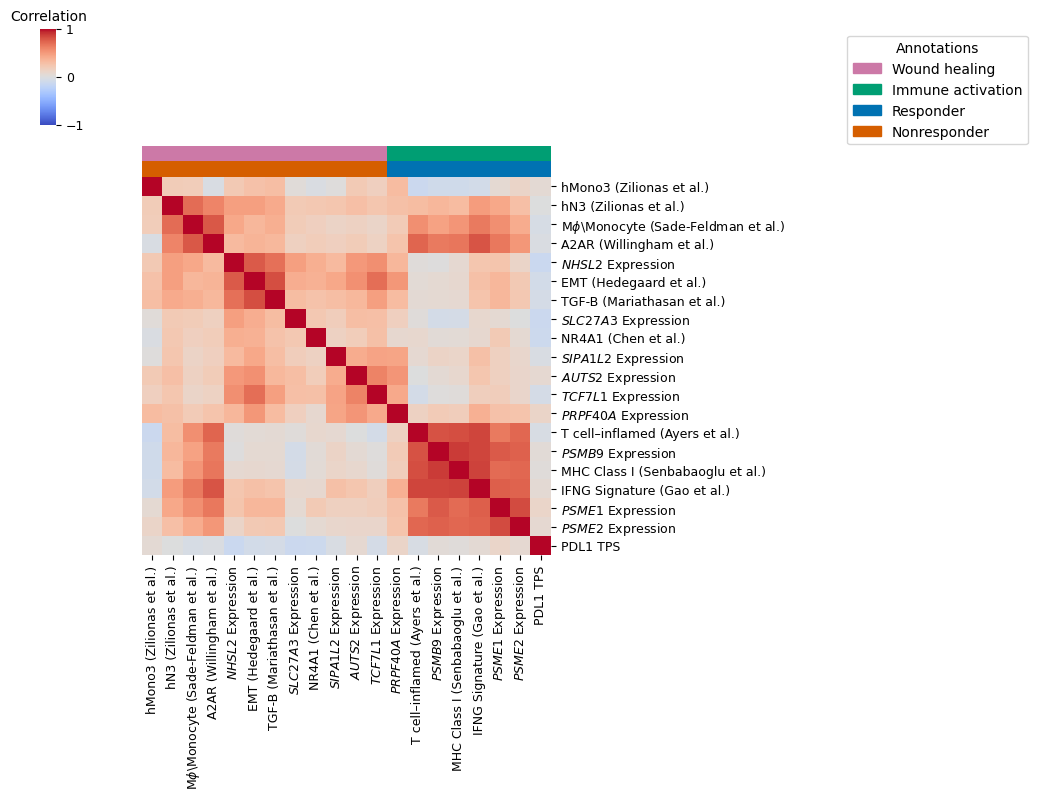

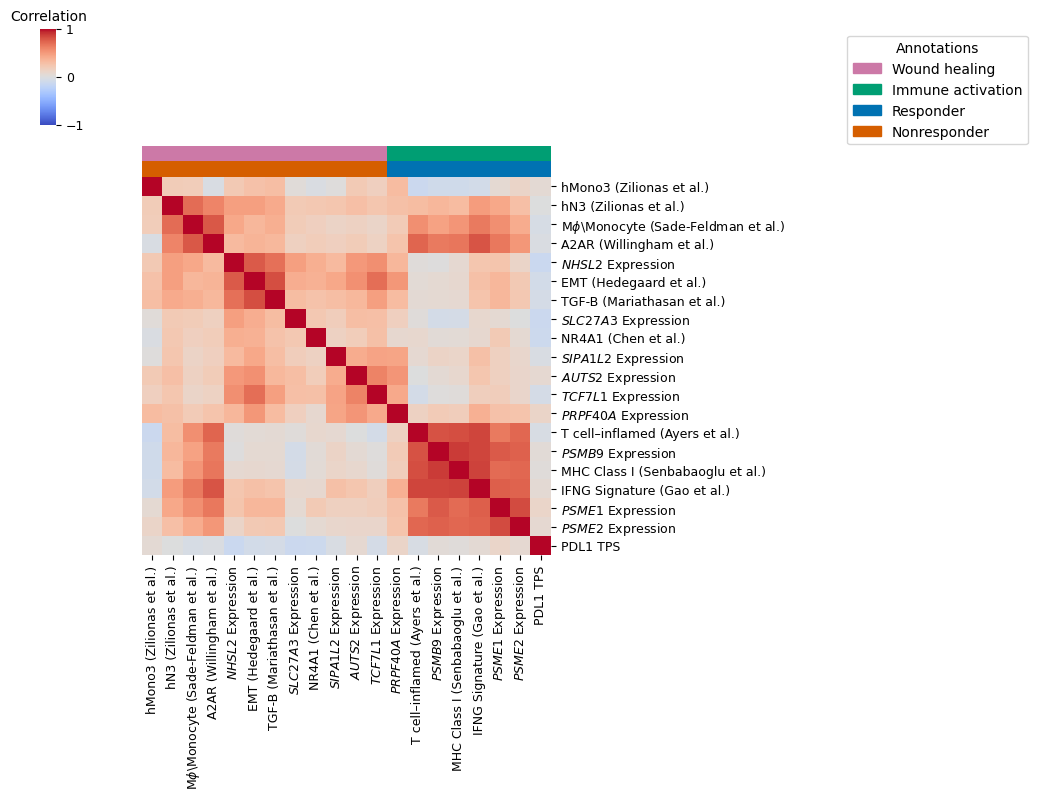

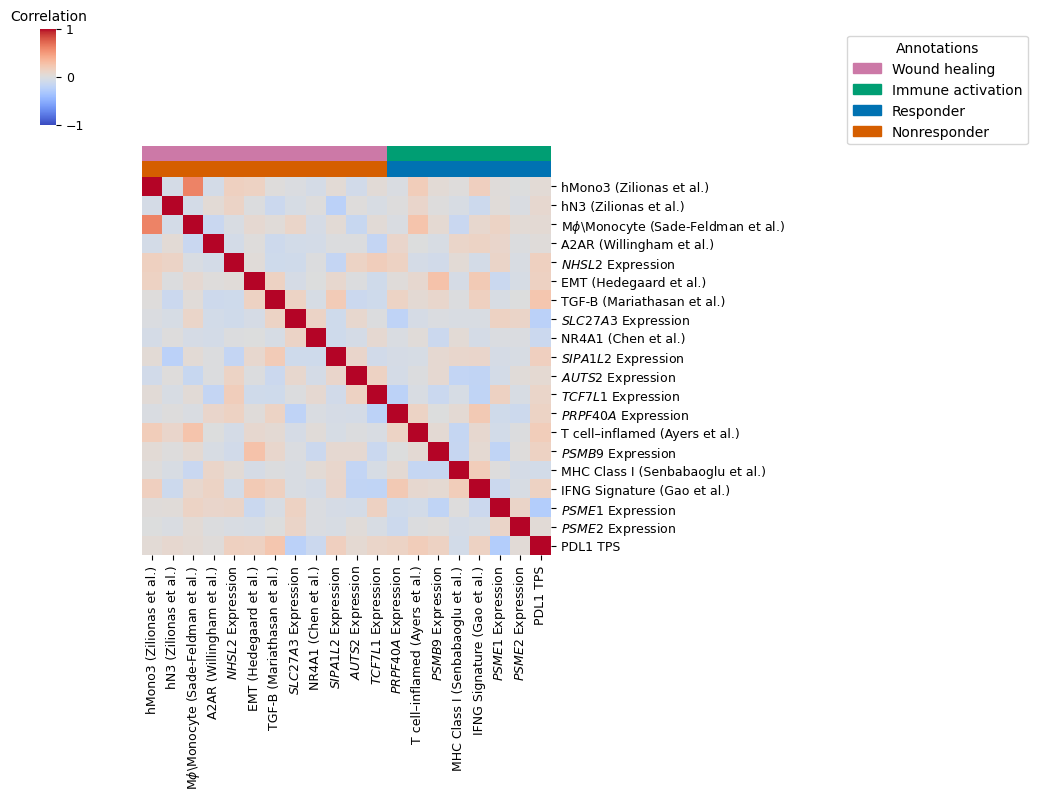

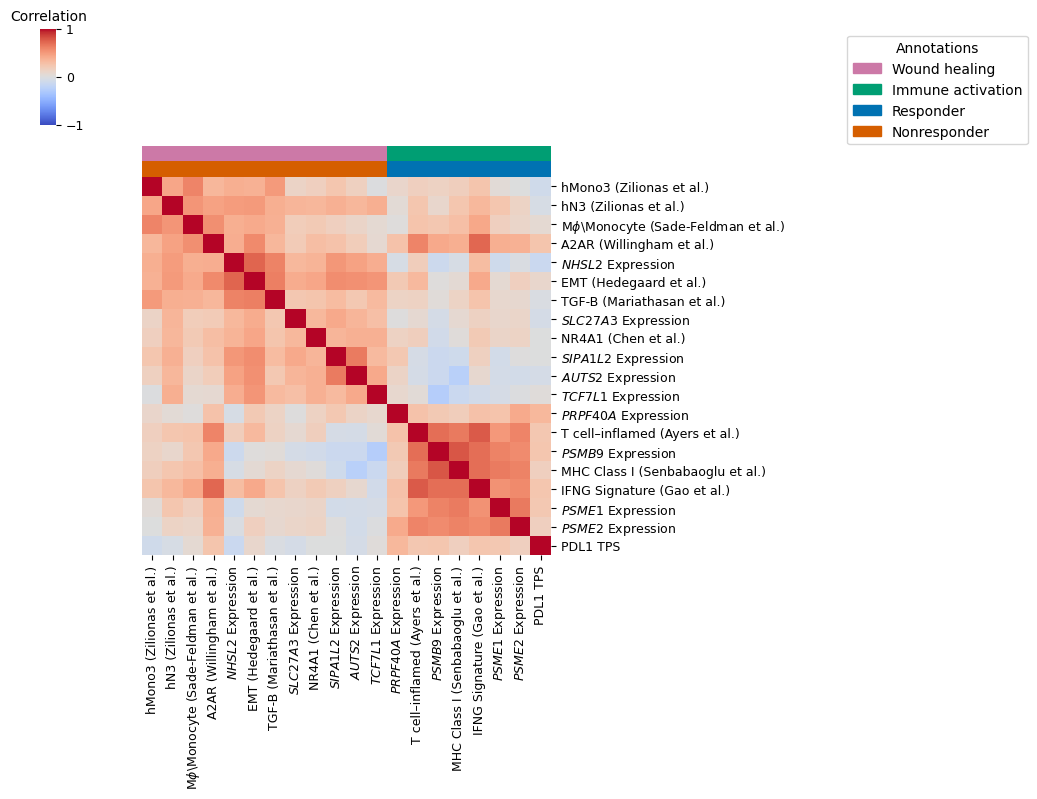

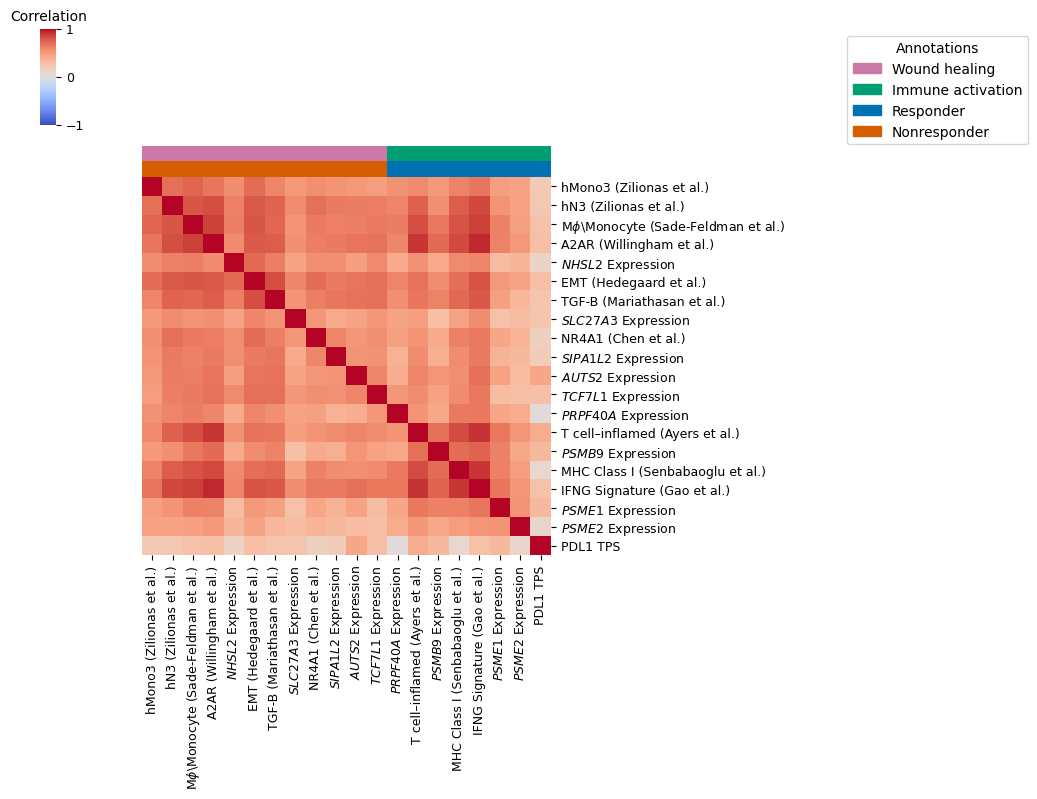

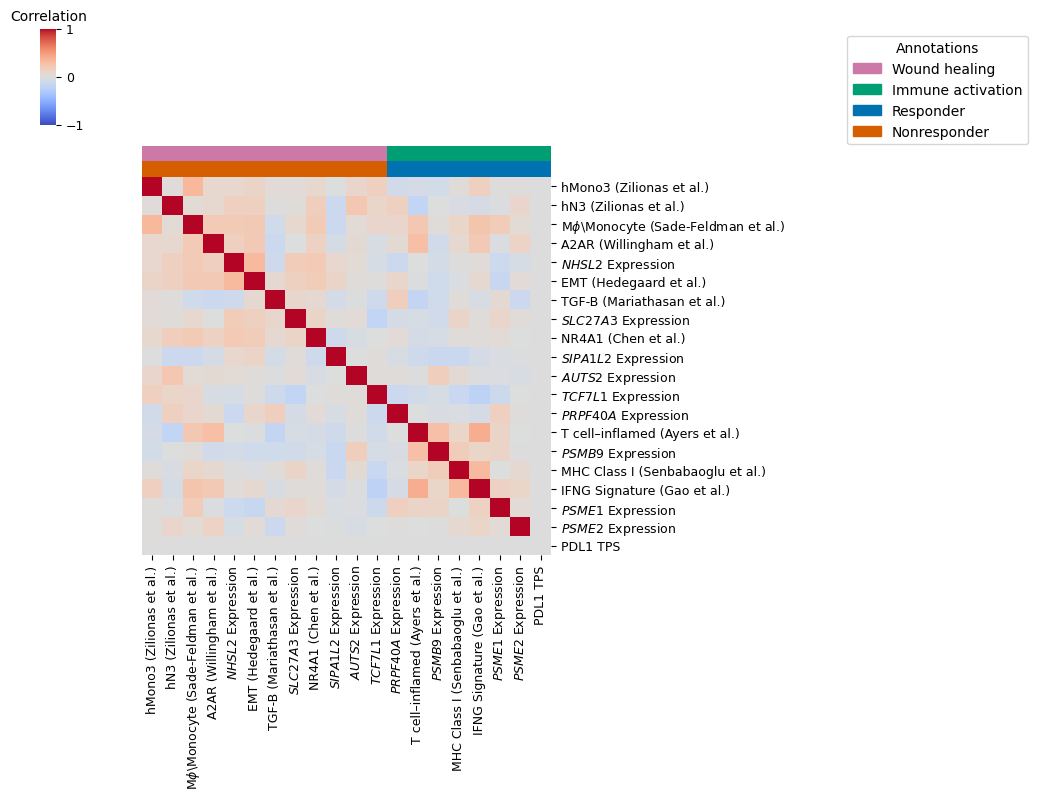

In [66]:
for k, corr in corr_res.items():
    g = plot_corr_heatmap_with_two_layers(corr, rename_map=rename_map, figsize=(8, 8))
    g.savefig(f'IntegrativeHeatmap/Heatmap_{k}.png', dpi=300, bbox_inches="tight", facecolor="white")
    g.savefig(f'IntegrativeHeatmap/Heatmap_{k}.pdf', dpi=300, bbox_inches="tight", facecolor="white")